# **Phase 0 – Project Setup**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import glob
import os

Mounted at /content/drive


# Set **folders**

In [4]:
input_folder = "/content/drive/MyDrive/NYC Yellow Taxi 2025 Data"
output_folder = "/content/drive/MyDrive/Cleaned NYC Taxi Data"

files = sorted(glob.glob(os.path.join(input_folder, "*.parquet")))

print("Total Files :", len(files))

Total Files : 12


# **Phase 1 – Inspect One Month**

In [5]:
df = pd.read_parquet(files[0])

df.head()

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,540149
trip_distance,0
RatecodeID,540149
store_and_fwd_flag,540149
PULocationID,0
DOLocationID,0
payment_type,0


# **Phase 1.1 – Clean Every Month (Recommended)**

In [7]:
for file in files:

    print(f"Processing {os.path.basename(file)}")

    df = pd.read_parquet(file)

    # Convert datetime
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    # Trip Duration
    df["trip_duration"] = (
        df["tpep_dropoff_datetime"] -
        df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    # Remove invalid rows
    df = df[df["fare_amount"] >= 0]
    df = df[df["trip_distance"] > 0]
    df = df[df["trip_duration"] > 0]

    # Remove duplicates
    df = df.drop_duplicates()

    # Remove outliers
    df = df[df["trip_duration"] <= 300]
    df = df[df["trip_distance"] <= 100]
    df = df[df["fare_amount"] <= 500]

    # Passenger count
    df = df[
        (df["passenger_count"] >= 1) &
        (df["passenger_count"] <= 6)
    ]

    # =====================
    # Feature Engineering
    # =====================

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

    df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

    df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()

    df["pickup_year"] = df["tpep_pickup_datetime"].dt.year

    df["is_weekend"] = (
        df["tpep_pickup_datetime"].dt.weekday >= 5
    )

    df["fare_per_mile"] = (
        df["fare_amount"] /
        df["trip_distance"]
    )

    df["tip_pct"] = (
        df["tip_amount"] /
        df["fare_amount"] * 100
    )

    df["tip_pct"] = df["tip_pct"].fillna(0)

    # Save
    filename = os.path.basename(file)

    df.to_parquet(
        os.path.join(output_folder, filename),
        index=False
    )

    print(f"Saved : {filename}")

    del df

Processing yellow_tripdata_2025-01.parquet
Saved : yellow_tripdata_2025-01.parquet
Processing yellow_tripdata_2025-02.parquet
Saved : yellow_tripdata_2025-02.parquet
Processing yellow_tripdata_2025-03.parquet
Saved : yellow_tripdata_2025-03.parquet
Processing yellow_tripdata_2025-04.parquet
Saved : yellow_tripdata_2025-04.parquet
Processing yellow_tripdata_2025-05.parquet
Saved : yellow_tripdata_2025-05.parquet
Processing yellow_tripdata_2025-06.parquet
Saved : yellow_tripdata_2025-06.parquet
Processing yellow_tripdata_2025-07.parquet
Saved : yellow_tripdata_2025-07.parquet
Processing yellow_tripdata_2025-08.parquet
Saved : yellow_tripdata_2025-08.parquet
Processing yellow_tripdata_2025-09.parquet
Saved : yellow_tripdata_2025-09.parquet
Processing yellow_tripdata_2025-10.parquet
Saved : yellow_tripdata_2025-10.parquet
Processing yellow_tripdata_2025-11.parquet
Saved : yellow_tripdata_2025-11.parquet
Processing yellow_tripdata_2025-12.parquet
Saved : yellow_tripdata_2025-12.parquet


In [8]:
import pandas as pd

df = pd.read_parquet(
    "/content/drive/MyDrive/Cleaned NYC Taxi Data/yellow_tripdata_2025-01.parquet"
)

print(df.shape)

df.isnull().sum()

(2815103, 28)


,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815103 entries, 0 to 2815102
Data columns (total 28 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

# Phase 2 – Create Monthly **Summary**

In [10]:
summary = []

files = sorted(glob.glob(output_folder + "/*.parquet"))

for file in files:

    df = pd.read_parquet(file)

    summary.append({

        "Month": df["pickup_month"].iloc[0],

        "Trips": len(df),

        "Revenue": df["total_amount"].sum(),

        "Average Fare": df["fare_amount"].mean(),

        "Average Distance": df["trip_distance"].mean(),

        "Average Duration": df["trip_duration"].mean(),

        "Average Tip %": df["tip_pct"].mean()

    })

    del df

summary_df = pd.DataFrame(summary)

summary_df

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Month,Trips,Revenue,Average Fare,Average Distance,Average Duration,Average Tip %
0,January,2815103,77018875.40,17.931358,3.176759,14.599751,inf
1,February,2656485,72502132.64,17.802635,3.105951,14.898699,inf
2,March,3078988,87711337.87,18.744544,3.316413,15.659668,inf
3,April,3057527,88159182.40,19.044708,3.302491,16.189098,inf
4,May,3191781,96421901.51,20.193222,3.472724,17.557186,inf
5,June,2910897,87437302.16,20.062872,3.514716,17.059907,NaN
6,July,2673849,79737026.84,20.041666,3.538432,16.799455,inf
7,August,2511130,75841547.59,20.485321,3.723904,16.904370,inf
8,September,2988969,91307649.05,20.667349,3.533518,18.279488,inf
9,October,3239367,98705068.69,20.578361,3.500955,18.443412,NaN


# **Phase** 3 – Create Sample Dataset (5%)

In [11]:
sample_dfs = []

for file in files:

    df = pd.read_parquet(file)

    sample_dfs.append(
        df.sample(frac=0.05, random_state=42)
    )

    del df

sample_df = pd.concat(
    sample_dfs,
    ignore_index=True
)

print(sample_df.shape)

(1753547, 28)


# **Phase 4 – Exploratory Data Analysis (EDA)**

**1. Monthly Trip Volumeext**

In [12]:
sample_df.groupby("pickup_month").size()

,0
pickup_month,
April,152875
August,125554
December,147306
February,132822
January,140755
July,133692
June,145545
March,153950
May,159591


**2. Monthly Revenue**

In [13]:
sample_df.groupby("pickup_month")["total_amount"].sum()

,total_amount
pickup_month,
April,4407892.23
August,3787995.67
December,4485363.64
February,3617795.78
January,3838416.01
July,3985001.21
June,4370031.43
March,4394493.56
May,4824919.39


**3. Average Fare**

In [14]:
sample_df.groupby("pickup_month")["fare_amount"].mean()

,fare_amount
pickup_month,
April,19.050002
August,20.454604
December,20.700238
February,17.756122
January,17.856639
July,20.037081
June,20.043810
March,18.790618
May,20.212766


**4. Peak Pickup Hour**

In [15]:
sample_df.groupby("pickup_hour").size()

,0
pickup_hour,
0,45157
1,29043
2,18553
3,11773
4,8219
5,10039
6,22268
7,44726
8,62593


**5. Trips by Day**

In [16]:
sample_df.groupby("pickup_day").size()

,0
pickup_day,
Friday,258972
Monday,223853
Saturday,253443
Sunday,212625
Thursday,274463
Tuesday,257588
Wednesday,272603


**6. Payment Type**

In [17]:
sample_df["payment_type"].value_counts()

,count
payment_type,
1,1506296
2,212651
4,26488
3,8112


**7. Passenger Count**

In [18]:
sample_df["passenger_count"].value_counts().sort_index()

,count
passenger_count,
1.0,1402221
2.0,243154
3.0,56879
4.0,37792
5.0,8619
6.0,4882


**8. Average Tip %**

In [19]:
sample_df.groupby("pickup_hour")["tip_pct"].mean()

,tip_pct
pickup_hour,
0,inf
1,21.573252
2,21.537144
3,20.608476
4,19.098421
5,17.532112
6,18.347814
7,20.094386
8,20.831679


**9. Fare Distribution**

In [20]:
sample_df["fare_amount"].describe()

,fare_amount
count,1.753547e+06
mean,1.972262e+01
std,1.829408e+01
min,0.000000e+00
25%,9.300000e+00
50%,1.350000e+01
75%,2.190000e+01
max,5.000000e+02


**10. Trip Distance Distribution**

In [21]:
sample_df["trip_distance"].describe()

,trip_distance
count,1.753547e+06
mean,3.421667e+00
std,4.527810e+00
min,1.000000e-02
25%,1.010000e+00
50%,1.700000e+00
75%,3.320000e+00
max,9.980000e+01


**11. Trip Duration Distribution**

In [22]:
sample_df["trip_duration"].describe()

,trip_duration
count,1.753547e+06
mean,1.699650e+01
std,1.464539e+01
min,1.666667e-02
25%,7.716667e+00
50%,1.275000e+01
75%,2.095000e+01
max,2.978167e+02


**12. Correlation**

In [23]:
sample_df[
    [
        "fare_amount",
        "trip_distance",
        "trip_duration",
        "tip_amount",
        "tip_pct"
    ]
].corr()

,fare_amount,trip_distance,trip_duration,tip_amount,tip_pct
fare_amount,1.000000,0.926240,0.800933,0.606015,-0.010727
trip_distance,0.926240,1.000000,0.792350,0.567046,-0.009697
trip_duration,0.800933,0.792350,1.000000,0.458830,-0.012474
tip_amount,0.606015,0.567046,0.458830,1.000000,0.029405
tip_pct,-0.010727,-0.009697,-0.012474,0.029405,1.000000


# **Phase 5 – Visualization**

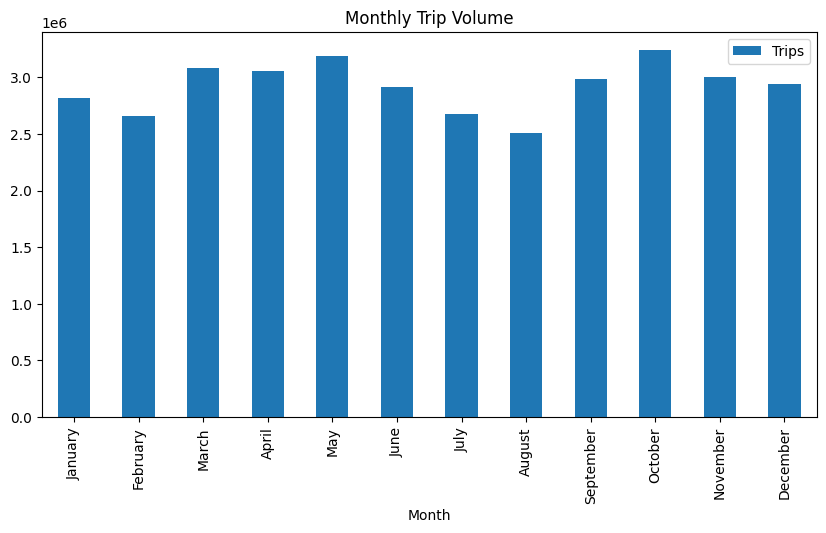

In [24]:
import matplotlib.pyplot as plt

summary_df.plot(
    x="Month",
    y="Trips",
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Trip Volume")
plt.show()

# **Phase 6 : Reporting**

**Create small CSV files that Tableau can load quickly.**

In [25]:
import os

output_dashboard = "/content/drive/MyDrive/NYC Dashboard"

os.makedirs(output_dashboard, exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


**CSV 1 – Monthly Summary**

In [26]:
summary_df.to_csv(
    os.path.join(output_dashboard, "monthly_summary.csv"),
    index=False
)

print("Monthly summary saved successfully!")

Monthly summary saved successfully!


In [27]:
monthly_summary = summary_df

In [28]:
# monthly_summary.to_csv(
#     os.path.join(output_dashboard, "monthly_summary.csv"),
#     index=False
# )

In [29]:
summary_df.head()

,Month,Trips,Revenue,Average Fare,Average Distance,Average Duration,Average Tip %
0,January,2815103,77018875.40,17.931358,3.176759,14.599751,inf
1,February,2656485,72502132.64,17.802635,3.105951,14.898699,inf
2,March,3078988,87711337.87,18.744544,3.316413,15.659668,inf
3,April,3057527,88159182.40,19.044708,3.302491,16.189098,inf
4,May,3191781,96421901.51,20.193222,3.472724,17.557186,inf


**CSV 2 – Hourly Demand**

In [30]:
hourly = []

for file in files:

    df = pd.read_parquet(file)

    temp = df.groupby(
        ["pickup_hour","is_weekend"]
    ).size().reset_index(name="Trips")

    hourly.append(temp)

hourly_df = pd.concat(hourly)

hourly_df = hourly_df.groupby(
    ["pickup_hour","is_weekend"]
)["Trips"].sum().reset_index()

hourly_df.to_csv(
    "/content/drive/MyDrive/NYC Dashboard/hourly_demand.csv",
    index=False
)

hourly_df

,pickup_hour,is_weekend,Trips
0,0,False,447666
1,0,True,455406
2,1,False,224365
3,1,True,358490
4,2,False,118274
5,2,True,253310
6,3,False,73724
7,3,True,165506
8,4,False,73344
9,4,True,90833


**CSV 3 – Payment Type**

In [31]:
payment=[]

for file in files:

    df=pd.read_parquet(file)

    temp=df.groupby(
        "payment_type"
    ).size().reset_index(name="Trips")

    payment.append(temp)

payment_df=pd.concat(payment)

payment_df=payment_df.groupby(
    "payment_type"
)["Trips"].sum().reset_index()

payment_df.to_csv(
    "/content/drive/MyDrive/NYC Dashboard/payment.csv",
    index=False
)

payment_df

,payment_type,Trips
0,1,30117969
1,2,4263161
2,3,157665
3,4,532197
4,5,1


**CSV 4 – Passenger Count**

In [32]:
passenger=[]

for file in files:

    df=pd.read_parquet(file)

    temp=df.groupby(
        "passenger_count"
    ).size().reset_index(name="Trips")

    passenger.append(temp)

passenger_df=pd.concat(passenger)

passenger_df=passenger_df.groupby(
    "passenger_count"
)["Trips"].sum().reset_index()

passenger_df.to_csv(
    "/content/drive/MyDrive/NYC Dashboard/passenger.csv",
    index=False
)

passenger_df

,passenger_count,Trips
0,1.0,28048412
1,2.0,4860776
2,3.0,1137694
3,4.0,754770
4,5.0,170565
5,6.0,98776


**CSV 5 – Tip Analysis**

In [33]:
tips=[]

for file in files:

    df=pd.read_parquet(file)

    temp=df.groupby(
        "pickup_hour"
    )["tip_pct"].mean().reset_index()

    tips.append(temp)

tip_df=pd.concat(tips)

tip_df=tip_df.groupby(
    "pickup_hour"
)["tip_pct"].mean().reset_index()

tip_df.to_csv(
    "/content/drive/MyDrive/NYC Dashboard/tip_analysis.csv",
    index=False
)

tip_df

,pickup_hour,tip_pct
0,0,inf
1,1,inf
2,2,inf
3,3,inf
4,4,19.113052
5,5,inf
6,6,inf
7,7,20.375294
8,8,inf
9,9,21.202404
